# Movie Recommendation System

## Dataset
MovieLens 100K

## Methods
- Collaborative Filtering
- Pearson Correlation

## Features
- Movie similarity recommendations
- Top rated movies
- Data visualization
- User recommendations

In [19]:
import pandas as pd
import numpy as np

In [2]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["movie_id", "title"]
)

movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [4]:
movie_data = ratings.merge(
    movies,
    on="movie_id"
)

movie_data.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [5]:
df = movie_data

user_movie_matrix = df.pivot_table(
    index="user_id",
    columns="title",
    values="rating"
)

user_movie_matrix.shape

(943, 1664)

In [6]:
def recommend_movies(movie_title, top_n=10):

    if movie_title not in user_movie_matrix.columns:

        matches = [
            title
            for title in user_movie_matrix.columns
            if movie_title.lower() in title.lower()
        ]

        if len(matches) == 0:
            print(f"No movie found matching '{movie_title}'.")
            return None

        elif len(matches) == 1:
            movie_title = matches[0]
            print(f"Using: {movie_title}")

        else:
            print("Multiple matches found:")
            for i, title in enumerate(matches[:10], start=1):
                print(f"{i}. {title}")
            return matches[:10]

    movie_ratings = user_movie_matrix[movie_title]

    similar = user_movie_matrix.corrwith(movie_ratings)

    corr_df = pd.DataFrame(
        similar,
        columns=["correlation"]
    )

    corr_df = corr_df.dropna()

    corr_df["num_ratings"] = df.groupby("title")["rating"].count()

    corr_df = corr_df[corr_df["num_ratings"] >= 30]

    corr_df = corr_df.drop(
        movie_title,
        errors="ignore"
    )

    return corr_df.sort_values(
        "correlation",
        ascending=False
    ).head(top_n)

In [7]:
id="7kqf9n"
recommend_movies("Star Wars (1977)").reset_index()

/Users/anitaganesan/Desktop/Movie_Project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/anitaganesan/Desktop/Movie_Project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/anitaganesan/Desktop/Movie_Project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3028: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/anitaganesan/Desktop/Movie_Project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2901: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/anitaganesan/Desktop/Movie_Project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2901: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,title,correlation,num_ratings
0,"Empire Strikes Back, The (1980)",0.747981,367
1,Return of the Jedi (1983),0.672556,507
2,Raiders of the Lost Ark (1981),0.536117,420
3,Night Falls on Manhattan (1997),0.515291,32
4,When We Were Kings (1996),0.515164,44
5,Brassed Off (1996),0.515108,32
6,Some Folks Call It a Sling Blade (1993),0.509016,41
7,Giant (1956),0.488093,51
8,Feeling Minnesota (1996),0.451848,32
9,"Kiss Me, Guido (1997)",0.425625,31


In [8]:
id="9j3y9w"
def top_movies(n=10):
    top = (
        df.groupby("title")["rating"]
        .agg(["mean", "count"])
        .sort_values(
            ["mean", "count"],
            ascending=False
        )
    )

    return top.head(n)

Matplotlib is building the font cache; this may take a moment.


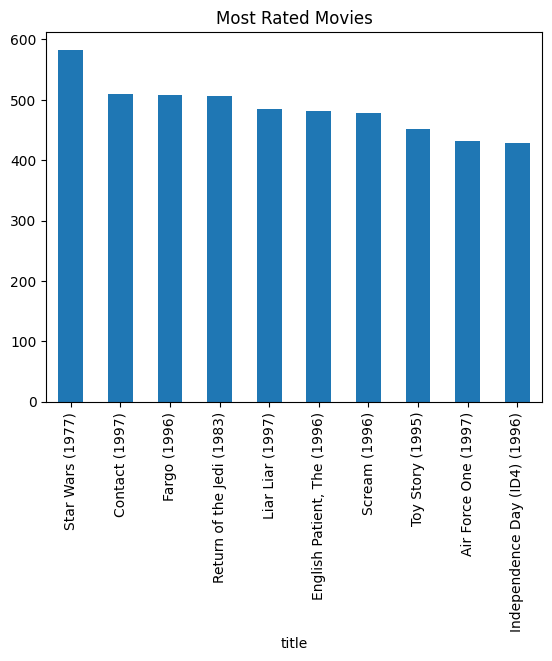

In [9]:
id="7a6j3m"
import matplotlib.pyplot as plt

(
    df["title"]
    .value_counts()
    .head(10)
    .plot(kind="bar")
)

plt.title("Most Rated Movies")
plt.show()

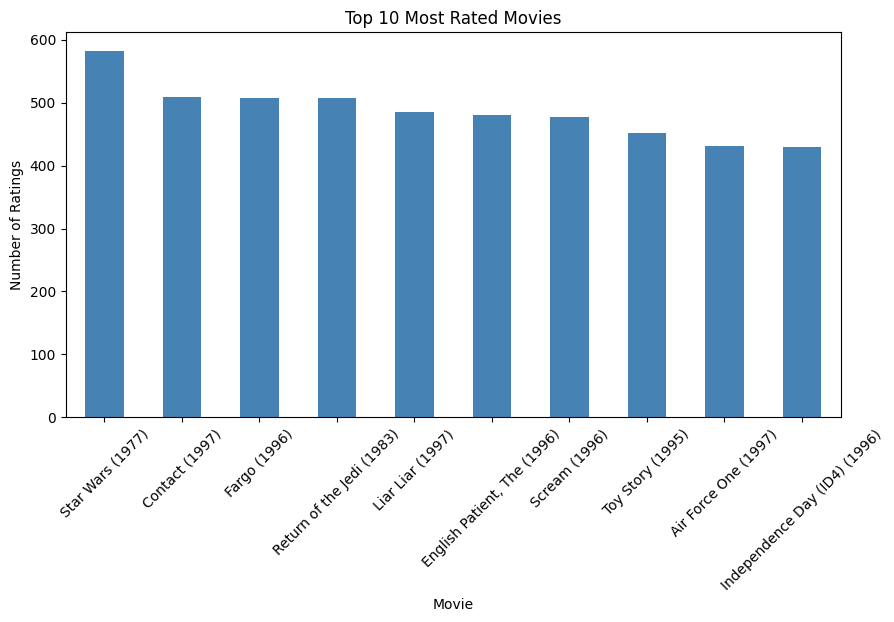

In [11]:
import matplotlib.pyplot as plt

top10 = (
    df["title"]
    .value_counts()
    .head(10)
)

top10.plot(
    kind="bar",
    figsize=(10,5),
    color="steelblue"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45)

plt.show()

In [12]:
def top_movies(n=10):

    movie_stats = (
        df.groupby("title")["rating"]
        .agg(
            avg_rating="mean",
            number_of_ratings="count"
        )
    )

    movie_stats = movie_stats[
        movie_stats["number_of_ratings"] >= 50
    ]

    return (
        movie_stats
        .sort_values(
            "avg_rating",
            ascending=False
        )
        .head(n)
    )

In [13]:
top_movies(10)

,avg_rating,number_of_ratings
title,,
"Close Shave, A (1995)",4.491071,112
Schindler's List (1993),4.466443,298
"Wrong Trousers, The (1993)",4.466102,118
Casablanca (1942),4.456790,243
Wallace & Gromit: The Best of Aardman Animation (1996),4.447761,67
"Shawshank Redemption, The (1994)",4.445230,283
Rear Window (1954),4.387560,209
"Usual Suspects, The (1995)",4.385768,267
Star Wars (1977),4.358491,583


In [14]:
def search_movie(word):

    results = [
        title
        for title in user_movie_matrix.columns
        if word.lower() in title.lower()
    ]

    return results[:20]

In [16]:
search_movie("star")

['Bastard Out of Carolina (1996)',
 'Evening Star, The (1996)',
 'Frankie Starlight (1995)',
 'Lone Star (1996)',
 'Star Kid (1997)',
 "Star Maker, The (Uomo delle stelle, L') (1995)",
 'Star Maps (1997)',
 'Star Trek III: The Search for Spock (1984)',
 'Star Trek IV: The Voyage Home (1986)',
 'Star Trek V: The Final Frontier (1989)',
 'Star Trek VI: The Undiscovered Country (1991)',
 'Star Trek: First Contact (1996)',
 'Star Trek: Generations (1994)',
 'Star Trek: The Motion Picture (1979)',
 'Star Trek: The Wrath of Khan (1982)',
 'Star Wars (1977)',
 'Stargate (1994)',
 'Stars Fell on Henrietta, The (1995)',
 'Starship Troopers (1997)',
 'Unhook the Stars (1996)']

In [20]:
movie = "Toy Story (1995)"

print("Because you liked:")
print(movie)

recommend_movies(movie)

Because you liked:
Toy Story (1995)


,correlation,num_ratings
title,,
"Transformers: The Movie, The (1986)",0.753673,32
Mouse Hunt (1997),0.736826,44
Farewell My Concubine (1993),0.672918,46
Fallen (1998),0.654585,41
187 (1997),0.651857,41
Raise the Red Lantern (1991),0.641535,58
Eddie (1996),0.623460,40
"Associate, The (1996)",0.620767,41
Once Upon a Time in the West (1969),0.606552,38
